# Development 5d: metrics for VGGT, and VGGT-Omega against VGGT (CPU)

Identical scoring to notebook `05b_one_block_metrics`, applied to the VGGT predictions from `05c_one_block_predict_vggt`.
Ground truth is rebuilt at VGGT's own input size (518x322); the scenes, LiDAR
points and every rule are the same. The last cell compares the two models
scene by scene, and needs notebook `05b_one_block_metrics` to have been run first.

**Before the first run:** fill in `docs/predictions_vggt_comparison.md`, then set
`PREDICTIONS_REGISTERED = True` in cell 1.

In [ ]:
# --- 1. Configuration ---
PREDICTIONS_REGISTERED = True     # set True only AFTER docs/predictions_vggt_comparison.md is filled in
PERSIST_MODE = "drive"
SPLIT, BLOCK = "val", 11
LAYERS = ["camera_keyframes", "lidar_motion_compensated_keyframes"]
CAMERA = "front_medium"
RUN_TAG = "phase5_val11_front_medium_vggt_1b"
OMEGA_RUN_TAG = "phase5_val11_front_medium"   # results of notebook `05b_one_block_metrics`, for the comparison

In [ ]:
# === CODE SYNC (auto-generated by `python -m vggt_aura.sync`, do not edit) ===
raise RuntimeError("The sync cell is empty. On your own machine, in the project folder, run:  python -m vggt_aura.sync   and reopen this notebook.")

In [3]:
# --- 3. The gate, then the session ---
if not PREDICTIONS_REGISTERED:
    raise RuntimeError("Fill in docs/predictions_vggt_comparison.md first, then set PREDICTIONS_REGISTERED = True in cell 1.")

from vggt_aura.session import start_session

session = start_session(persist_mode=PERSIST_MODE, require_gpu=False)

Mounted at /content/drive
installing vggt_omega
installing pybind11
installing fzi_aura
persist root: /content/drive/MyDrive/vggt-omega-aura-benchmark
data root   : /content/data/fzi-aura (runtime disk, wiped at session end)


In [4]:
# --- 4. Camera AND LiDAR layers of the block ---
import time
from vggt_aura import (aura_data as ad, evaluation as ev, geometry as geo, ground_truth as gtm,
                       inference as inf, metrics as mt, objects as ob, pins)

chunks, scene_blocks, hub_files = ad.fetch_release_tables(session.data_root / "_release_tables")
BLOCK_SCENE_IDS = ad.block_scene_ids(scene_blocks, SPLIT, BLOCK)
if ad.block_on_disk(session.data_root, BLOCK_SCENE_IDS, LAYERS):
    print("block already on disk with", LAYERS)
else:
    started = time.time()
    ad.download_block(session.data_root, SPLIT, BLOCK, BLOCK_SCENE_IDS, LAYERS)
    print(f"download and extract took {(time.time() - started) / 60:.1f} min")

$ /usr/bin/python3 -m fzi_aura.download /content/data/fzi-aura --revision 3404bd6b8fcd6eed53a0ec7610650a6393aabb49 --splits val --scene-ids-file /content/data/fzi-aura/_scene_ids_val_block000011.txt --layers camera_keyframes,lidar_motion_compensated_keyframes --jobs 8 --verify
download and extract took 13.3 min


In [5]:
# --- 5. Score every scene that has predictions ---
import json
import numpy as np
import pandas as pd
from fzi_aura import FZIAURADataset

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)
CHECKPOINT = inf.VGGT_NAME              # the folder the VGGT predictions were saved under
dataset = FZIAURADataset(session.data_root, split=SPLIT)
PARAMS = {"two_sided": gtm.OcclusionParams(mode="two_sided"), "none": gtm.OcclusionParams(mode="none")}
all_rows, all_rows_no_occlusion, scene_records, timing = [], [], [], []

for scene_id in BLOCK_SCENE_IDS:
    scene = dataset.get_scene(scene_id)
    npz_path, json_path = inf.prediction_paths(session.persist_root, scene.name, CAMERA, CHECKPOINT)
    if not npz_path.is_file():
        print("no predictions for", scene_id, "- run notebook `05c_one_block_predict_vggt` first; scene skipped")
        continue
    started = time.time()
    arrays, _ = inf.load_predictions(npz_path, json_path)
    frames = inf.select_frames(scene, CAMERA)
    assert [f.timestamp_ns for f in frames] == arrays["timestamps_ns"].tolist(), "frames differ from the predicted ones"
    height, width = (int(v) for v in arrays["input_hw"])
    TRUTH_TAG = f"{width}x{height}"               # keeps this ground truth apart from the 640x400 one

    calibration = scene.calibration()
    P = calibration.camera_projection_matrix(CAMERA)
    native = calibration.sensor(f"camera/{CAMERA}")["intrinsics"]
    K = geo.scale_intrinsics(P[0, 0], P[1, 1], P[0, 2], P[1, 2], (native["width"], native["height"]), (width, height))
    classes = json.loads((scene.path / "labels" / "semantic" / "classes.json").read_text(encoding="utf-8"))
    class_names = {int(c["id"]): c["name"] for c in classes["semantic_classes"]}
    drop_ids = gtm.excluded_class_ids(class_names)
    lidars = list(scene.available_lidars())

    for mode, params in PARAMS.items():
        truth = gtm.build_scene_truth(frames, CAMERA, lidars, K, width, height, params, drop_ids)
        labels = ob.scene_motion_labels(frames, CAMERA, truth)
        rows, record = ev.evaluate_scene(scene_id, arrays, truth, labels, class_names, K[0], K[1])
        if mode == "two_sided":
            all_rows.append(rows)
            scene_records.append({**record, **{k: v for k, v in ad.scene_summary(scene).items()
                                               if k in ("road_type", "weather", "weather_group", "lighting", "speed_band",
                                                        "speed_kph_median", "sunrise_raw", "sunset_raw", "start_hour_utc")}})
            truth_npz, truth_json = gtm.truth_paths(session.persist_root, scene.name, CAMERA, tag=TRUTH_TAG)
            gtm.save_scene_truth(truth_npz, truth_json, truth, [f.timestamp_ns for f in frames],
                                 {"scene_id": scene_id, "camera": CAMERA, "lidars": lidars, "model_wh": [width, height],
                                  "occlusion": params.as_dict(), "dataset_revision": pins.AURA_DATASET_REVISION})
        else:
            all_rows_no_occlusion.append(rows)
    timing.append(time.time() - started)
    print(f"{scene_id:26} {len(frames)} frames  {timing[-1]:5.1f} s")

rows = pd.concat(all_rows, ignore_index=True)
rows_no_occlusion = pd.concat(all_rows_no_occlusion, ignore_index=True)
scenes = pd.DataFrame(scene_records)
print()
print(f"scored {len(scenes)} scenes, median {np.median(timing):.0f} s per scene")

2025-07-15-13-11-47|24     40 frames   49.1 s
2025-06-11-13-47-25|25     40 frames   39.6 s
2025-06-13-07-09-37|78     40 frames   38.7 s
2025-07-15-14-15-47|71     40 frames   45.4 s
2025-07-15-13-11-47|63     40 frames   45.4 s
2025-06-11-12-27-55|207    40 frames   33.3 s
2025-07-15-13-11-47|110    40 frames   45.0 s
2025-06-16-12-35-26|82     39 frames   46.0 s
2025-06-16-12-35-26|2      40 frames   44.1 s
2025-07-15-13-11-47|10     40 frames   54.1 s
2025-07-15-13-11-47|48     40 frames   54.8 s
2025-06-11-13-47-25|24     40 frames   36.5 s
2025-06-11-12-27-55|211    40 frames   40.6 s
2025-06-16-12-35-26|73     40 frames   45.9 s
2025-07-15-14-15-47|59     40 frames   44.3 s
2025-07-15-13-11-47|74     40 frames   45.1 s
2025-06-12-08-12-52|38     40 frames   40.6 s
2025-06-16-13-29-59|6      40 frames   44.2 s
2025-07-15-14-15-47|46     40 frames   47.6 s
2025-06-13-07-09-37|39     40 frames   32.0 s

scored 20 scenes, median 45 s per scene


In [6]:
# --- 6. Save everything the tables are built from ---
out_dir = session.persist_root / "metrics" / RUN_TAG
out_dir.mkdir(parents=True, exist_ok=True)
rows.to_csv(out_dir / "depth_rows.csv", index=False)
rows_no_occlusion.to_csv(out_dir / "depth_rows_no_occlusion_handling.csv", index=False)
scenes.to_csv(out_dir / "scenes.csv", index=False)
ad.save_json(out_dir / "run.json", {
    "run_tag": RUN_TAG, "split": SPLIT, "block": BLOCK, "camera": CAMERA, "checkpoint": CHECKPOINT,
    "dataset_revision": pins.AURA_DATASET_REVISION, "model_code_commit": pins.VGGT_COMMIT,
    "protocols": mt.PROTOCOLS, "primary_protocol": mt.PRIMARY_PROTOCOL, "depth_range_m": [mt.DEPTH_MIN_M, mt.DEPTH_MAX_M],
    "occlusion": PARAMS["two_sided"].as_dict(), "moving_speed_mps": ob.MOVING_SPEED_MPS, "parked_speed_mps": ob.PARKED_SPEED_MPS,
    "min_pixels_per_stratum": ev.MIN_PIXELS_PER_STRATUM, "min_scenes": ev.DEFAULT_MIN_SCENES, "scenes": len(scenes)})
for scene_id in scenes["scene_id"]:
    if not session.manifest.is_done(scene_id, f"metrics/{RUN_TAG}"):
        session.manifest.mark_done(scene_id, f"metrics/{RUN_TAG}")
print("saved to", out_dir)

saved to /content/drive/MyDrive/vggt-omega-aura-benchmark/metrics/phase5_val11_front_medium_vggt_1b


## Results

Every mean is a mean over SCENES, with a 95% bootstrap interval over scenes.
`thin = True` means fewer than 5 scenes support that row: read it as a
description of those scenes, not as a finding.

In [7]:
# --- 7. Depth: every protocol, then the strata under the primary protocol ---
report = ev.build_report(rows, scenes)


def show(title, table, digits=4):
    print()
    print("=====", title, "=====")
    print(table.round(digits).to_string(index=False) if len(table) else "(no rows)")


show("AbsRel by alignment protocol (all pixels)", report["headline_by_protocol"])
show("moving vs parked vs background pixels  [sequence_scale]", report["motion"])
show("paired differences within scenes (a minus b; positive = a is worse)", report["moving_vs_background"])
show("by ground-truth depth  [sequence_scale]", report["depth_band"])
show("by semantic group  [sequence_scale]", report["semantic_group"])
show("by the model's own confidence  [sequence_scale]", report["confidence_quartile"])


===== AbsRel by alignment protocol (all pixels) =====
         protocol  n_scenes   pixels  abs_rel  ci_low  ci_high  thin  delta125
      frame_scale        20 35044567   0.0695  0.0596   0.0811 False    0.9544
frame_scale_shift        20 35044567   0.0635  0.0530   0.0759 False    0.9610
       pose_scale        20 35044567   0.0910  0.0751   0.1114 False    0.9440
   sequence_scale        20 35044567   0.0762  0.0658   0.0887 False    0.9508
        unaligned        20 35044567   0.9819  0.9777   0.9857 False    0.0000

===== moving vs parked vs background pixels  [sequence_scale] =====
         stratum  n_scenes   pixels  abs_rel  ci_low  ci_high  thin  delta125
      background        20 32429033   0.0667  0.0584   0.0765 False    0.9580
   moving object        17   332053   0.2245  0.1507   0.3204 False    0.8042
   parked object        18  2185342   0.1570  0.1017   0.2314 False    0.8959
uncertain object        14    97759   0.2574  0.1292   0.4657 False    0.7745

===== paire

In [8]:
# --- 8. Pose, intrinsics, scale agreement, and the trap-3 bound on moving-object ground truth ---
show("camera pose (scenes that actually move)", report["pose_moving_scenes_only"])
print("near-stationary scenes kept out of the pose table:", int(scenes["near_stationary"].sum()), "of", len(scenes))
show("focal length error, depth/pose scale agreement, moving-object ground-truth bound", report["intrinsics_scale_and_trap3"])
print()
print("fx_rel_err < 0 means the predicted focal length is too SHORT.")
print("pose_scale_over_depth_scale = 1 means depth and camera translation agree on the scale.")
print("moving_gt_bound_rel is how wrong the LiDAR depth of a moving object can itself be (trap 3), as a share of its depth.")
print("Compare it with the moving-object AbsRel above before reading anything into that number.")


===== camera pose (scenes that actually move) =====
                    metric  n_scenes    mean  ci_low  ci_high
       rotation_deg_median        20  0.6968  0.4816   0.9587
    translation_deg_median        20  0.7941  0.6324   0.9773
                      auc3        20 75.8511 66.9582  84.1798
                     auc30        20 96.5314 94.8613  97.9970
    auc30_authors_unsigned        20 96.5316 94.8618  97.9975
          ate_scale_only_m        20  1.9088  0.9602   3.4346
ate_scale_only_pct_of_path        20  1.3921  1.1540   1.6662
                ate_sim3_m        20  1.2709  0.5660   2.3713
near-stationary scenes kept out of the pose table: 0 of 20

===== focal length error, depth/pose scale agreement, moving-object ground-truth bound =====
                     metric  n_scenes    mean  ci_low  ci_high
          fx_rel_err_median        20 -0.0772 -0.0926  -0.0642
          fy_rel_err_median        20 -0.1143 -0.1288  -0.1020
              fx_spread_rel        20  0.0466  

In [9]:
# --- 9. Scene-level strata, and how much the occlusion rule matters ---
for attribute in ev.SCENE_ATTRIBUTES:
    show(f"AbsRel by {attribute}  [sequence_scale, scene level]", report[f"by_{attribute}"])
print()
print("sunrise / sunset raw values (first scene):", scenes.loc[0, "sunrise_raw"], scenes.loc[0, "sunset_raw"])

no_occlusion = ev.build_report(rows_no_occlusion, scenes)
compare = report["motion"][["stratum", "n_scenes", "abs_rel"]].merge(
    no_occlusion["motion"][["stratum", "abs_rel"]], on="stratum", suffixes=("_two_sided", "_no_occlusion_handling"))
show("sensitivity to the occlusion rule  [sequence_scale]", compare)


===== AbsRel by road_type  [sequence_scale, scene level] =====
road_type  n_scenes  abs_rel  ci_low  ci_high  thin
 overland         2   0.0912  0.0735   0.1089  True
    urban        18   0.0746  0.0640   0.0865 False

===== AbsRel by weather_group  [sequence_scale, scene level] =====
weather_group  n_scenes  abs_rel  ci_low  ci_high  thin
          dry        17   0.0772  0.0654   0.0907 False
          wet         3   0.0705  0.0611   0.0786  True

===== AbsRel by lighting  [sequence_scale, scene level] =====
lighting  n_scenes  abs_rel  ci_low  ci_high  thin
     day        20   0.0762  0.0658   0.0887 False

===== AbsRel by speed_band  [sequence_scale, scene level] =====
  speed_band  n_scenes  abs_rel  ci_low  ci_high  thin
  20-50 km/h         8   0.0639  0.0555   0.0733 False
   5-20 km/h         6   0.0815  0.0628   0.1067 False
over 50 km/h         2   0.0912  0.0735   0.1089  True
under 5 km/h         4   0.0854  0.0554   0.1154  True

sunrise / sunset raw values (first sce

In [10]:
# --- 10. Per-scene table, worst first ---
primary = rows[(rows["protocol"] == mt.PRIMARY_PROTOCOL) & (rows["stratum_type"] == "all")][["scene_id", "abs_rel", "delta125", "n_pixels"]]
per_scene = primary.merge(scenes[["scene_id", "road_type", "weather_group", "speed_kph_median", "gt_path_m", "near_stationary",
                                  "auc30", "ate_scale_only_pct_of_path", "fx_rel_err_median", "pose_scale_over_depth_scale",
                                  "moving_pixels"]], on="scene_id").sort_values("abs_rel", ascending=False)
print(per_scene.round(3).to_string(index=False))
per_scene.to_csv(out_dir / "per_scene.csv", index=False)

               scene_id  abs_rel  delta125  n_pixels road_type weather_group  speed_kph_median  gt_path_m  near_stationary  auc30  ate_scale_only_pct_of_path  fx_rel_err_median  pose_scale_over_depth_scale  moving_pixels
 2025-06-11-13-47-25|24    0.142     0.858   1527426     urban           dry            19.415     70.769            False 99.895                       1.600             -0.067                        1.100          46326
 2025-06-11-13-47-25|25    0.122     0.944   1399537     urban           dry             3.965     38.329            False 99.286                       0.990             -0.086                        1.001          24740
 2025-06-16-12-35-26|82    0.109     0.948   1915943     urban           dry             2.265     12.791            False 98.506                       1.256             -0.058                        0.949             11
 2025-06-12-08-12-52|38    0.109     0.885   1520295  overland           dry            76.340    418.672           

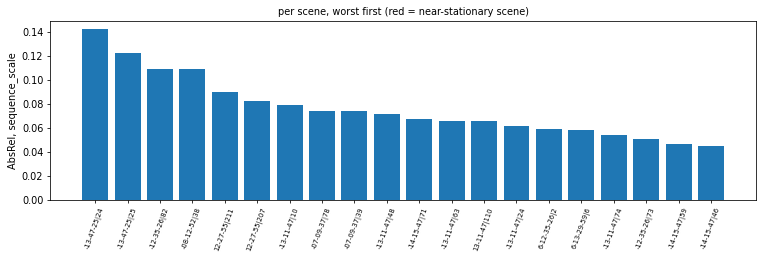

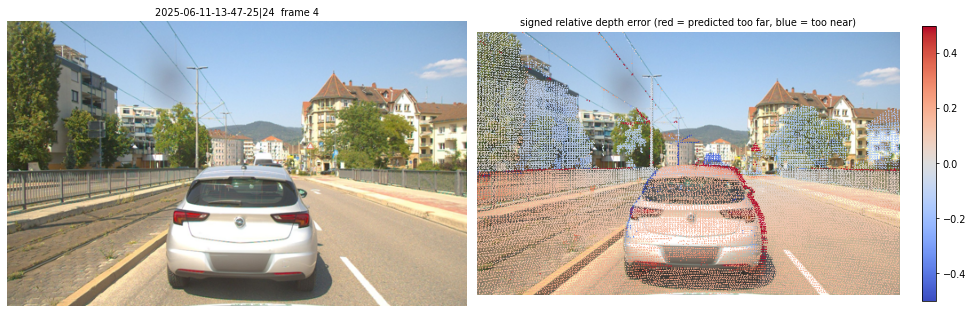

worst scene: 2025-06-11-13-47-25|24 | worst frame: 4 | that frame's AbsRel: 0.166


In [11]:
# --- 11. Figures: per-scene error, and an error map of the worst frame of the worst scene ---
import matplotlib.pyplot as plt
from PIL import Image

figure_dir = session.persist_root / "figures" / "phase5"
figure_dir.mkdir(parents=True, exist_ok=True)

figure, axis = plt.subplots(figsize=(11, 3.8), dpi=70)
colours = ["tab:red" if flag else "tab:blue" for flag in per_scene["near_stationary"]]
axis.bar(range(len(per_scene)), per_scene["abs_rel"], color=colours)
axis.set_xticks(range(len(per_scene)))
axis.set_xticklabels([s[-12:] for s in per_scene["scene_id"]], rotation=70, fontsize=7)
axis.set_ylabel("AbsRel, sequence_scale")
axis.set_title("per scene, worst first (red = near-stationary scene)", fontsize=10)
figure.tight_layout()
figure.savefig(figure_dir / f"{RUN_TAG}_per_scene.png", dpi=70)
plt.show()

worst_id = per_scene.iloc[0]["scene_id"]
scene = dataset.get_scene(worst_id)
arrays, _ = inf.load_predictions(*inf.prediction_paths(session.persist_root, scene.name, CAMERA, CHECKPOINT))
truth, _, _ = gtm.load_scene_truth(*gtm.truth_paths(session.persist_root, scene.name, CAMERA, tag=TRUTH_TAG))
frames = inf.select_frames(scene, CAMERA)
pred_all = np.concatenate([arrays["depth"][i, t["v"].astype(int), t["u"].astype(int)] for i, t in enumerate(truth)])
gt_all = np.concatenate([t["depth_m"] for t in truth])
keep_all = (gt_all >= mt.DEPTH_MIN_M) & (gt_all <= mt.DEPTH_MAX_M)
scale = mt.median_scale(pred_all[keep_all], gt_all[keep_all])
errors = []
for i, t in enumerate(truth):
    keep = (t["depth_m"] >= mt.DEPTH_MIN_M) & (t["depth_m"] <= mt.DEPTH_MAX_M)
    pred = arrays["depth"][i, t["v"].astype(int), t["u"].astype(int)] * scale
    errors.append(np.mean(np.abs(pred[keep] - t["depth_m"][keep]) / t["depth_m"][keep]) if keep.any() else np.nan)
worst_frame = int(np.nanargmax(errors))
t = truth[worst_frame]
keep = (t["depth_m"] >= mt.DEPTH_MIN_M) & (t["depth_m"] <= mt.DEPTH_MAX_M)
signed = (arrays["depth"][worst_frame, t["v"].astype(int), t["u"].astype(int)] * scale - t["depth_m"]) / t["depth_m"]
height, width = (int(v) for v in arrays["input_hw"])
image = np.asarray(Image.open(frames[worst_frame].camera_path(CAMERA)).convert("RGB").resize((width, height)))
figure, axes = plt.subplots(1, 2, figsize=(14, 4.6), dpi=70)
axes[0].imshow(image); axes[0].set_title(f"{worst_id}  frame {worst_frame}", fontsize=10)
axes[1].imshow(image)
points = axes[1].scatter(t["u"][keep], t["v"][keep], c=np.clip(signed[keep], -0.5, 0.5), cmap="coolwarm", s=1.5, linewidths=0)
axes[1].set_title("signed relative depth error (red = predicted too far, blue = too near)", fontsize=10)
figure.colorbar(points, ax=axes[1], fraction=0.03)
for axis in axes:
    axis.axis("off")
figure.tight_layout()
figure.savefig(figure_dir / f"{RUN_TAG}_worst_frame.png", dpi=70)
plt.show()
print("worst scene:", worst_id, "| worst frame:", worst_frame, "| that frame's AbsRel: %.3f" % errors[worst_frame])

## VGGT-Omega against VGGT, scene by scene

`difference_a_minus_b` is VGGT-Omega minus VGGT, averaged over the scenes both
models have. For AbsRel, angles and ATE a NEGATIVE difference means VGGT-Omega
is better; for AUC a POSITIVE one does. An interval that includes zero means
this block cannot tell the two models apart on that quantity.

In [12]:
# --- 12. The comparison. Needs the results of notebook `05b_one_block_metrics` on Drive ---
omega_dir = session.persist_root / "metrics" / OMEGA_RUN_TAG
if not (omega_dir / "depth_rows.csv").is_file():
    print("No VGGT-Omega results found at", omega_dir)
    print("Run notebook `05b_one_block_metrics` first, then re-run this cell.")
else:
    omega_rows = pd.read_csv(omega_dir / "depth_rows.csv")
    omega_scenes = pd.read_csv(omega_dir / "scenes.csv")
    comparison = ev.compare_models(omega_rows, omega_scenes, rows, scenes, "vggt_omega", "vggt")
    comparison.to_csv(out_dir / "vggt_omega_minus_vggt.csv", index=False)
    show("VGGT-Omega minus VGGT, paired by scene  [sequence_scale]", comparison)
    print()
    print("ground truth pixels per scene, median: VGGT-Omega (640x400)",
          int(omega_rows[(omega_rows.protocol == mt.PRIMARY_PROTOCOL) & (omega_rows.stratum_type == "all")]["n_pixels"].median()),
          "| VGGT (518x322)", int(rows[(rows.protocol == mt.PRIMARY_PROTOCOL) & (rows.stratum_type == "all")]["n_pixels"].median()))


===== VGGT-Omega minus VGGT, paired by scene  [sequence_scale] =====
                   quantity  n_scenes  vggt_omega    vggt  difference_a_minus_b  ci_low  ci_high  scenes_where_a_is_lower
         AbsRel, all pixels        20      0.0542  0.0762               -0.0221 -0.0318  -0.0141                       18
         AbsRel, background        20      0.0499  0.0667               -0.0168 -0.0240  -0.0109                       19
      AbsRel, parked object        18      0.0836  0.1570               -0.0734 -0.1388  -0.0235                       17
      AbsRel, moving object        17      0.1754  0.2245               -0.0491 -0.1254   0.0087                        8
        rotation_deg_median        20      0.5528  0.6968               -0.1440 -0.2603  -0.0038                       17
     translation_deg_median        20      0.8018  0.7941                0.0077 -0.1054   0.1132                        8
                      auc30        20     98.1942 96.5314                1.6